# Earthquake Magnitude

<a target="_blank" href="https://colab.research.google.com/github/AI4EPS/EPS130_Seismology/blob/main/notebooks/earthquake_magnitude_lecture.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

On September 22, 2025, a **M4.3 earthquake** struck just 2 km from UC Berkeley. You may have felt it!

In this notebook, we'll compute the **local magnitude $M_L$** of this earthquake from raw seismograms — step by step — and reproduce the official NCEDC catalog value. Along the way, we'll learn why different magnitude types and different agencies can report different numbers for the same earthquake.

USGS event page: [nc75240492](https://earthquake.usgs.gov/earthquakes/eventpage/nc75240492/executive)

In [1]:
!pip install obspy cartopy -q

import numpy as np
import matplotlib.pyplot as plt
import requests
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.invsim import corn_freq_2_paz, paz_to_freq_resp
from obspy.geodetics import gps2dist_azimuth

---
## 1. The Event

Here's what the USGS reported for this earthquake:

| Agency | Magnitude | Type | Depth | Status |
|--------|-----------|------|-------|--------|
| **NC** (N. California) | 4.29 | Mw | 7.6 km | Reviewed |
| **US** (USGS National) | 4.3 | Mwr | 6.6 km | Reviewed |
| **AT** (Austria) | 4.3 | Ml | 9.0 km | Reviewed |
| **EW** (Earthworm) | 4.6 | Mw | 9.0 km | Automatic |

The NC network also reported three different magnitude types:
- $M_w$ = 4.29 (moment magnitude)
- $M_L$ = 4.55 (local magnitude)
- $M_d$ = 4.63 (duration magnitude)

**Why don't these agree?** To understand, let's compute $M_L$ ourselves from scratch.

### The $M_L$ Pipeline

Here's the processing chain we'll follow:

$$\boxed{\text{Raw counts}} \xrightarrow{\text{remove response}} \boxed{\text{Displacement}} \xrightarrow{\text{simulate WA}} \boxed{\text{WA trace}} \xrightarrow{\text{measure amp}} \boxed{A} \xrightarrow{\text{distance correction}} \boxed{M_L}$$

Each step has a physical reason — let's go through them one at a time.

---
## 2. Step 1: Download Seismograms

We download broadband recordings from the **BK (Berkeley)** seismic network. We choose stations at 30–200 km distance, where the $M_L$ formula works best.

In [2]:
# Connect to the Northern California Earthquake Data Center
client = Client("NCEDC")

# Earthquake origin time and location (from the USGS/NC catalog)
origin_time = UTCDateTime("2025-09-22T09:56:12.52")
eq_lat, eq_lon, eq_depth = 37.8630, -122.2540, 7.6  # km

# BK (Berkeley) network stations at 30–200 km distance
station_list = ["LCOS", "BUCI", "JASP", "MLKN", "MCCM", "TESL",
                "FARB", "MHC", "MTOS", "SAO", "CMB"]

t1 = origin_time - 30
t2 = origin_time + 180

# Download 3-component broadband waveforms with instrument calibration info
streams = {}
for sta in station_list:
    try:
        st = client.get_waveforms("BK", sta, "*", "HH?", t1, t2,
                                  attach_response=True)
        streams[sta] = st
        print(f"  {sta}: {len(st)} traces")
    except Exception as e:
        print(f"  {sta}: not available")

print(f"\nDownloaded data from {len(streams)} stations")

  LCOS: 3 traces


  BUCI: 3 traces


  JASP: 3 traces


  MLKN: 3 traces


  MCCM: 3 traces


...

  FARB: 3 traces


  MHC: 3 traces


  MTOS: 3 traces


  SAO: 3 traces


  CMB: 3 traces

Downloaded data from 11 stations


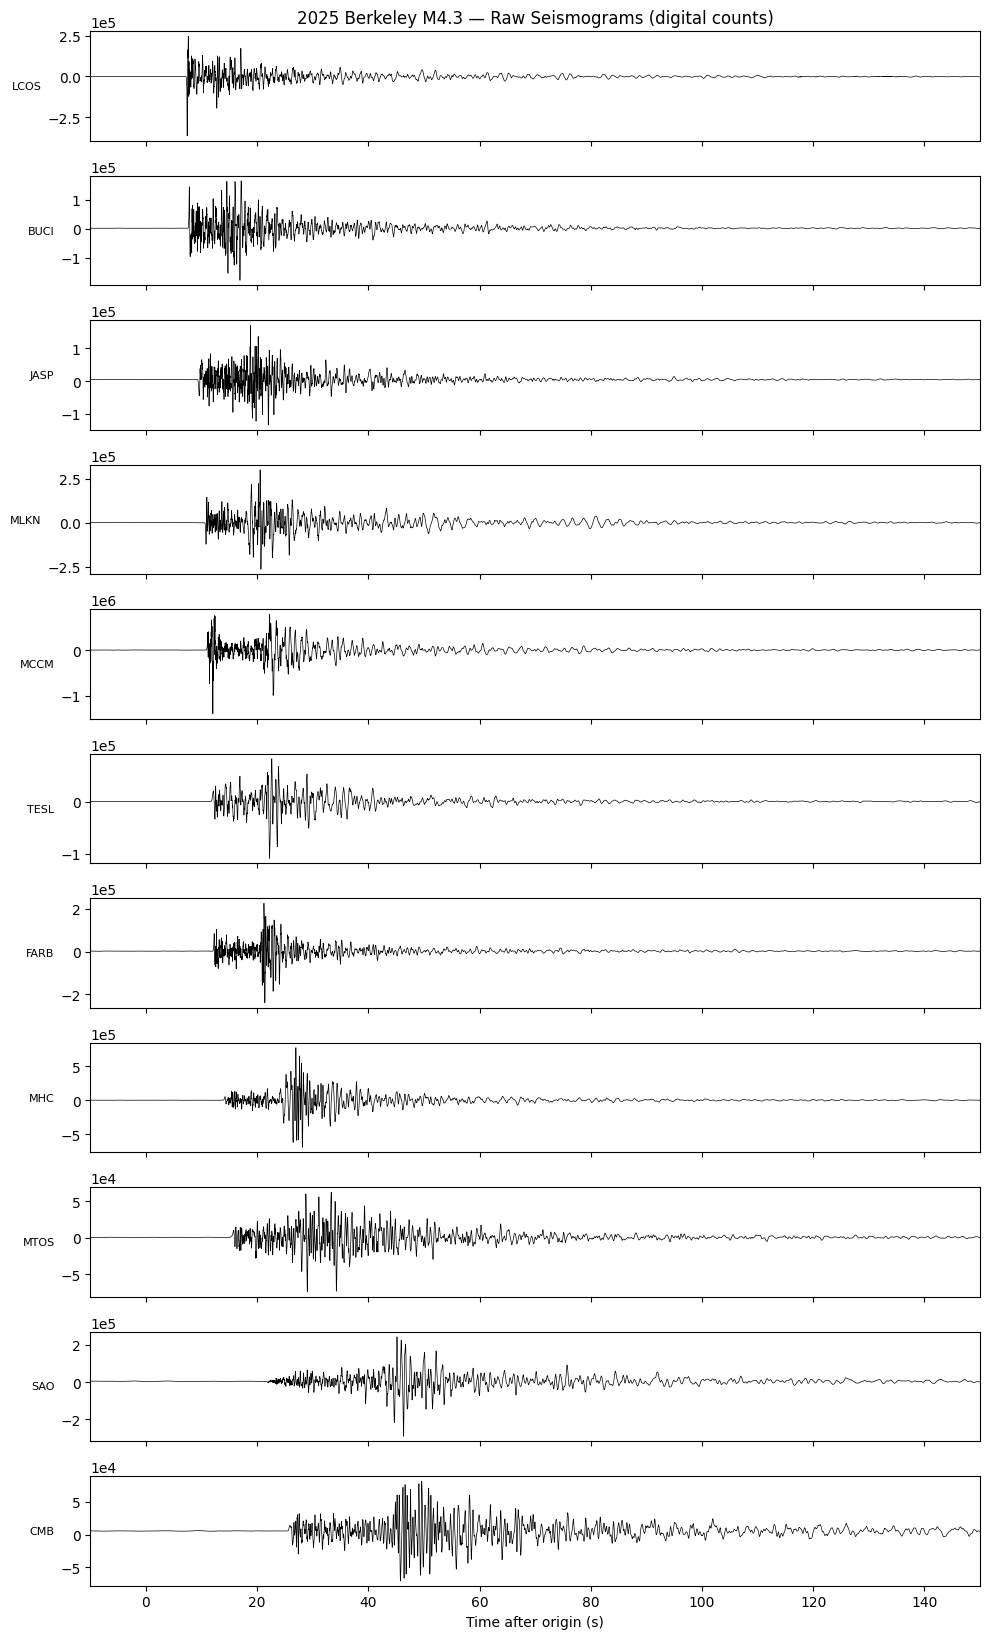

In [3]:
# Plot vertical component — y-axis is digital counts (not physical units yet)
fig, axes = plt.subplots(len(streams), 1, figsize=(10, 1.5 * len(streams)), sharex=True)

for ax, (sta, st) in zip(axes, streams.items()):
    tr = st.select(component="Z")[0]
    times = tr.times(reftime=origin_time)
    ax.plot(times, tr.data, "k", lw=0.5)
    ax.set_ylabel(sta, fontsize=8, rotation=0, ha="right", va="center")
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
    ax.set_xlim(-10, 150)

axes[-1].set_xlabel("Time after origin (s)")
axes[0].set_title("2025 Berkeley M4.3 — Raw Seismograms (digital counts)")
plt.tight_layout()
plt.show()

The y-axis shows **digital counts** — just numbers from the analog-to-digital converter. Notice that:
- Nearby stations (LCOS, BUCI) have **larger amplitudes** than distant stations (SAO, CMB)
- But we **can't compare amplitudes** between stations yet, because each instrument has a different sensitivity

To get physically meaningful amplitudes, we need to **remove the instrument response**.

---
## 3. Step 2: Remove the Instrument Response

Every seismometer has a **transfer function** that describes how it converts ground motion into digital counts. This transfer function depends on the specific instrument — different models have different sensitivities and frequency responses.

To recover the **true ground displacement** (in meters), we deconvolve the instrument's transfer function from the recorded signal. In ObsPy, this is done with `remove_response()`.

/Users/weiqiang/.local/miniconda3/lib/python3.12/site-packages/obspy/core/inventory/response.py:2318: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower center", ncol=3, fontsize='small')


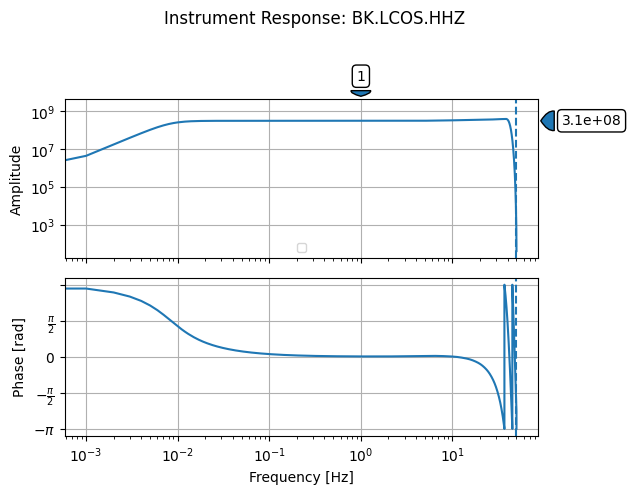

Top: amplitude response (how much the instrument amplifies each frequency)
Bottom: phase response


In [4]:
# Plot the instrument response (transfer function) for one station
sta0 = list(streams.keys())[0]
tr_example = streams[sta0].select(component="Z")[0]

fig = tr_example.stats.response.plot(min_freq=0.001, show=False)
fig.suptitle(f"Instrument Response: BK.{sta0}.HHZ", y=1.02)
plt.tight_layout()
plt.show()

print(f"Top: amplitude response (how much the instrument amplifies each frequency)")
print(f"Bottom: phase response")

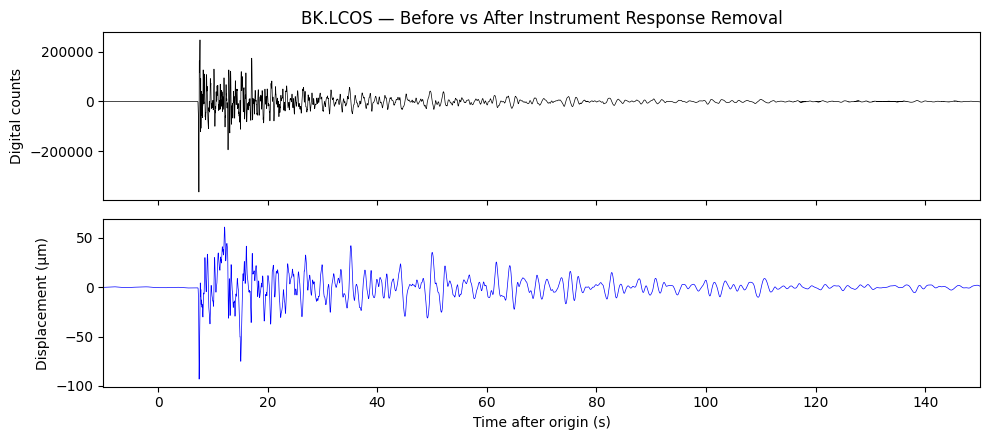

Now the y-axis has physical units: ground displacement in micrometers (μm)


In [5]:
# Remove instrument response: counts → true ground displacement (meters)
streams_disp = {}
for sta, st in streams.items():
    st_disp = st.copy()
    st_disp.detrend("demean")          # remove DC offset
    st_disp.detrend("linear")          # remove linear drift
    st_disp.taper(0.05)               # smooth the edges
    st_disp.remove_response(output="DISP")  # deconvolve → displacement (m)
    streams_disp[sta] = st_disp

# Before vs after for one station
tr_raw = streams[sta0].select(component="Z")[0]
tr_disp = streams_disp[sta0].select(component="Z")[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)
times = tr_raw.times(reftime=origin_time)

ax1.plot(times, tr_raw.data, "k", lw=0.5)
ax1.set_ylabel("Digital counts")
ax1.set_title(f"BK.{sta0} — Before vs After Instrument Response Removal")
ax1.set_xlim(-10, 150)

ax2.plot(times, tr_disp.data * 1e6, "b", lw=0.5)
ax2.set_ylabel("Displacement (μm)")
ax2.set_xlabel("Time after origin (s)")

plt.tight_layout()
plt.show()

print("Now the y-axis has physical units: ground displacement in micrometers (μm)")

---
## 4. Step 3: Simulate the Wood-Anderson Seismograph

Richter defined $M_L$ in 1935 using the **Wood-Anderson (WA)** torsion seismograph. To compute $M_L$ today, we must simulate what the WA would have recorded.

The WA acts like a **bandpass filter** — it's most sensitive around 0.5–2 Hz:

| Parameter | Value |
|-----------|-------|
| Natural period | 0.8 s (1.25 Hz) |
| Damping | 0.8 |
| Magnification | 2080 |

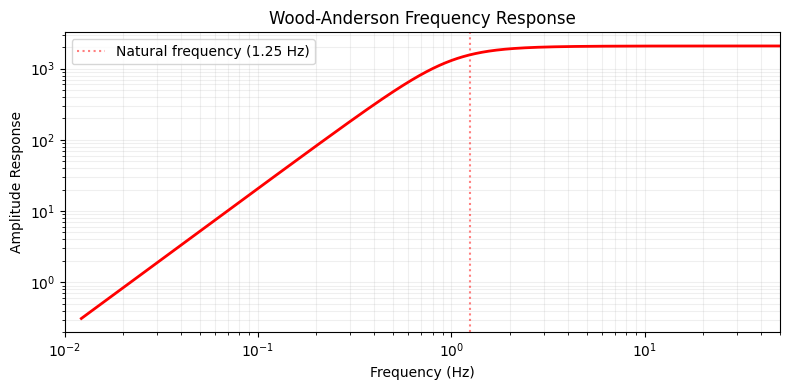

The WA is most sensitive around 0.5–2 Hz.
It attenuates very low and very high frequencies.


In [6]:
# Wood-Anderson instrument response (poles-zeros representation)
wa_paz = corn_freq_2_paz(1.0, damp=0.8)
wa_paz["sensitivity"] = 2080
wa_paz["zeros"] = [0j, 0j]

# Compute and plot the WA frequency response
nfft = 8192
t_samp = 0.01
h_wa, f_wa = paz_to_freq_resp(wa_paz["poles"], wa_paz["zeros"],
                               wa_paz["sensitivity"], t_samp, nfft, freq=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(f_wa[1:], np.abs(h_wa[1:]), "r", lw=2)
ax.axvline(1.25, color="r", ls=":", alpha=0.5, label="Natural frequency (1.25 Hz)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude Response")
ax.set_title("Wood-Anderson Frequency Response")
ax.legend()
ax.grid(True, which="both", alpha=0.2)
ax.set_xlim(0.01, 50)
plt.tight_layout()
plt.show()

print("The WA is most sensitive around 0.5–2 Hz.")
print("It attenuates very low and very high frequencies.")

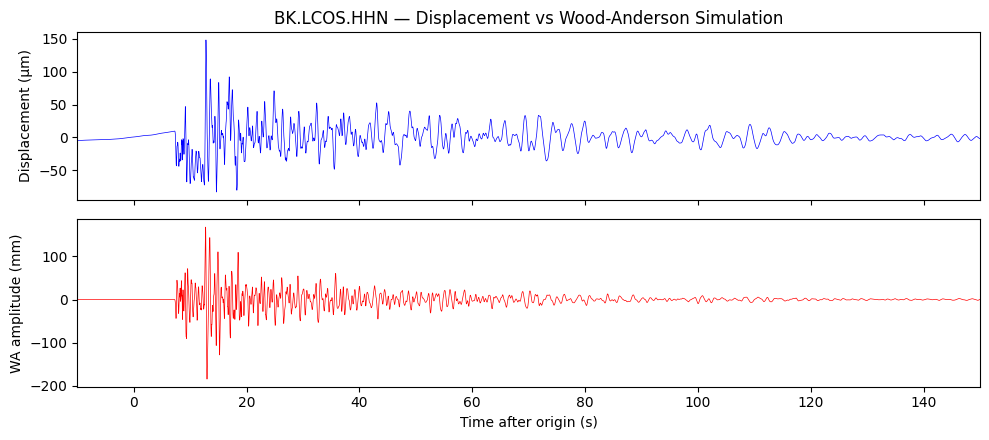

The WA filters out long-period drift and high-frequency noise.


In [7]:
# Apply WA response to the displacement data (simulate what WA would record)
streams_wa = {}
for sta, st in streams_disp.items():
    st_wa = st.copy()
    for tr in st_wa:
        tr.stats.response = None  # already removed
    st_wa.simulate(paz_simulate=wa_paz)
    streams_wa[sta] = st_wa

# Compare: broadband displacement vs WA-filtered for one station
tr_d = streams_disp[sta0].select(component="N")[0]
tr_w = streams_wa[sta0].select(component="N")[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4.5), sharex=True)

ax1.plot(tr_d.times(reftime=origin_time), tr_d.data * 1e6, "b", lw=0.5)
ax1.set_ylabel("Displacement (μm)")
ax1.set_title(f"BK.{sta0}.HHN — Displacement vs Wood-Anderson Simulation")
ax1.set_xlim(-10, 150)

ax2.plot(tr_w.times(reftime=origin_time), tr_w.data * 1e3, "r", lw=0.5)
ax2.set_ylabel("WA amplitude (mm)")
ax2.set_xlabel("Time after origin (s)")

plt.tight_layout()
plt.show()

print("The WA filters out long-period drift and high-frequency noise.")

---
## 5. Step 4: Measure the Amplitude

We measure the **half peak-to-trough amplitude** — half the distance between the largest positive and negative peaks — in the **S-wave window** (where most energy arrives for local earthquakes).

Let's first visualize this on a single station.

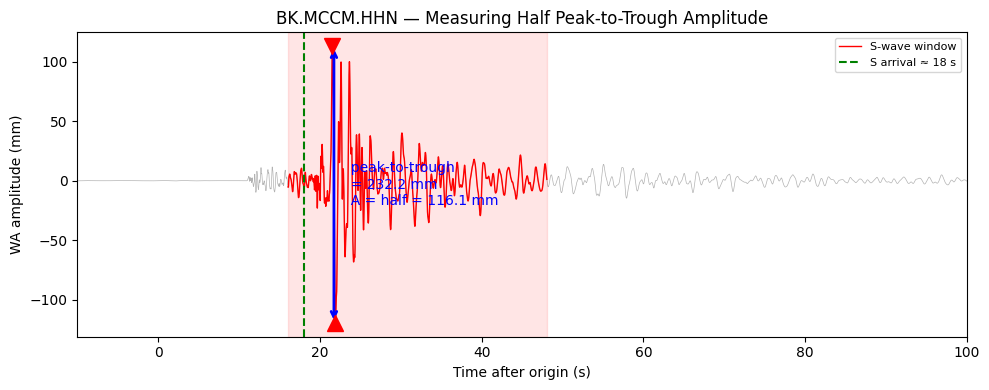

Station: BK.MCCM, Distance: 63.3 km
Half peak-to-trough amplitude: A = 116.1 mm


In [8]:
# Demonstrate amplitude measurement on station MCCM
sta_demo = "MCCM"
tr_demo = streams_wa[sta_demo].select(component="N")[0]
times_demo = tr_demo.times(reftime=origin_time)

# Distance and estimated S-wave arrival time
inv = client.get_stations(network="BK", station=sta_demo, level="station")
dist_m, _, _ = gps2dist_azimuth(eq_lat, eq_lon, inv[0][0].latitude, inv[0][0].longitude)
dist_km = dist_m / 1000.0
s_arrival = dist_km / 3.5  # S-wave velocity ≈ 3.5 km/s

# S-wave window: where the largest amplitudes are
s_start = s_arrival - 2
s_end = s_arrival + 30
s_mask = (times_demo >= s_start) & (times_demo <= s_end)
s_data = tr_demo.data[s_mask] * 1e3  # convert to mm

# Find peak and trough, compute half peak-to-trough
peak_val = s_data.max()
trough_val = s_data.min()
half_p2p = (peak_val - trough_val) / 2

# Plot with annotations
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_demo, tr_demo.data * 1e3, "k", lw=0.5, alpha=0.3)
ax.plot(times_demo[s_mask], s_data, "r", lw=1, label="S-wave window")

peak_idx = np.argmax(s_data)
trough_idx = np.argmin(s_data)
s_times = times_demo[s_mask]
ax.plot(s_times[peak_idx], peak_val, "rv", markersize=12, zorder=5)
ax.plot(s_times[trough_idx], trough_val, "r^", markersize=12, zorder=5)

# Arrow showing peak-to-trough measurement
mid_t = (s_times[peak_idx] + s_times[trough_idx]) / 2
ax.annotate("", xy=(mid_t, peak_val), xytext=(mid_t, trough_val),
            arrowprops=dict(arrowstyle="<->", color="blue", lw=2))
ax.text(mid_t + 1, (peak_val + trough_val)/2,
        f"  peak-to-trough\n  = {peak_val - trough_val:.1f} mm\n  A = half = {half_p2p:.1f} mm",
        fontsize=10, color="blue", va="center")

ax.axvspan(s_start, s_end, alpha=0.1, color="red")
ax.axvline(s_arrival, color="green", ls="--", lw=1.5, label=f"S arrival ≈ {s_arrival:.0f} s")
ax.set_xlabel("Time after origin (s)")
ax.set_ylabel("WA amplitude (mm)")
ax.set_title(f"BK.{sta_demo}.HHN — Measuring Half Peak-to-Trough Amplitude")
ax.legend(fontsize=8)
ax.set_xlim(-10, 100)
plt.tight_layout()
plt.show()

print(f"Station: BK.{sta_demo}, Distance: {dist_km:.1f} km")
print(f"Half peak-to-trough amplitude: A = {half_p2p:.1f} mm")

---
## 6. Step 5: Apply the $M_L$ Formula

The amplitude $A$ decreases with distance — a station farther from the earthquake records a smaller signal. To get a distance-independent magnitude, we apply a **distance correction**.

The Northern California Seismic Network uses the **Bakun & Joyner (1984)** formula:

$$\boxed{M_L = \log_{10} A + \log_{10} R + 0.00301 \, R + 0.70}$$

where:
- $A$ = half peak-to-trough WA amplitude in **mm**
- $R$ = **hypocentral distance** $= \sqrt{\Delta^2 + d^2}$ in km ($\Delta$ = epicentral distance, $d$ = depth)

Let's apply this to all our stations.

In [9]:
# Compute epicentral distance, hypocentral distance, and S-arrival for each station
station_coords = {}
for sta in streams:
    inv = client.get_stations(network="BK", station=sta, level="station")
    sta_lat = inv[0][0].latitude
    sta_lon = inv[0][0].longitude
    dist_m, _, _ = gps2dist_azimuth(eq_lat, eq_lon, sta_lat, sta_lon)
    dist_km = dist_m / 1000.0
    hypo_km = np.sqrt(dist_km**2 + eq_depth**2)  # 3D distance including depth
    s_arrival = dist_km / 3.5
    station_coords[sta] = {"lat": sta_lat, "lon": sta_lon,
                           "dist_km": dist_km, "hypo_km": hypo_km,
                           "s_arrival": s_arrival}

In [10]:
# Measure amplitude and compute ML for all stations, both horizontal components
ml_results = []

for sta, st in streams_wa.items():
    coords = station_coords[sta]
    s_arr = coords["s_arrival"]
    R = coords["hypo_km"]

    for comp in ["N", "E"]:
        tr_list = st.select(component=comp)
        if not tr_list:
            continue
        tr = tr_list[0]
        times = tr.times(reftime=origin_time)

        # S-wave window
        s_mask = (times >= s_arr - 2) & (times <= s_arr + 30)
        s_data = tr.data[s_mask]
        if len(s_data) == 0:
            continue

        # Half peak-to-trough amplitude in mm
        amp_mm = (s_data.max() - s_data.min()) / 2 * 1e3

        # Bakun-Joyner (1984) formula
        ml = np.log10(amp_mm) + np.log10(R) + 0.00301 * R + 0.70

        ml_results.append({"station": sta, "comp": comp,
                           "dist_km": coords["dist_km"], "hypo_km": R,
                           "amp_mm": amp_mm, "ml": ml})

ml_results.sort(key=lambda r: r["dist_km"])
ml_all = np.array([r["ml"] for r in ml_results])

print(f"{'Station':<10} {'Comp':<5} {'Δ (km)':>7} {'R (km)':>7} {'A (mm)':>9} {'ML':>7}")
print("-" * 50)
for r in ml_results:
    print(f"  {r['station']:<8} {r['comp']:<5} {r['dist_km']:>6.1f} {r['hypo_km']:>6.1f} {r['amp_mm']:>8.2f} {r['ml']:>6.2f}")
print("-" * 50)
print(f"  {'Median':>13} {'':>7} {'':>7} {'':>9} {np.median(ml_all):>6.2f}")
print(f"  {'Std':>13} {'':>7} {'':>7} {'':>9} {np.std(ml_all):>6.2f}")
print(f"\n  NCEDC catalog ML = 4.55")
print(f"  Our ML = {np.median(ml_all):.2f} ± {np.std(ml_all):.2f}")

Station    Comp   Δ (km)  R (km)    A (mm)      ML
--------------------------------------------------
  LCOS     N       36.9   37.6   176.13   4.63
  LCOS     E       36.9   37.6   160.78   4.60
  BUCI     N       41.7   42.3   129.08   4.57
  BUCI     E       41.7   42.3   126.29   4.56
  JASP     N       51.0   51.6   132.73   4.69
  JASP     E       51.0   51.6   118.90   4.64
  MLKN     N       57.7   58.2    67.33   4.47
  MLKN     E       57.7   58.2    78.13   4.53
  MCCM     N       63.3   63.7   116.08   4.76
  MCCM     E       63.3   63.7    94.48   4.67
  TESL     N       64.6   65.1    92.27   4.67
  TESL     E       64.6   65.1    85.49   4.64
  FARB     N       68.3   68.7   116.93   4.81
  FARB     E       68.3   68.7    99.26   4.74
  MHC      N       79.1   79.5    72.71   4.70
  MHC      E       79.1   79.5    72.67   4.70
  MTOS     N       90.9   91.2    26.68   4.36
  MTOS     E       90.9   91.2    23.51   4.31
  SAO      N      141.4  141.6    23.30   4.64
  SAO

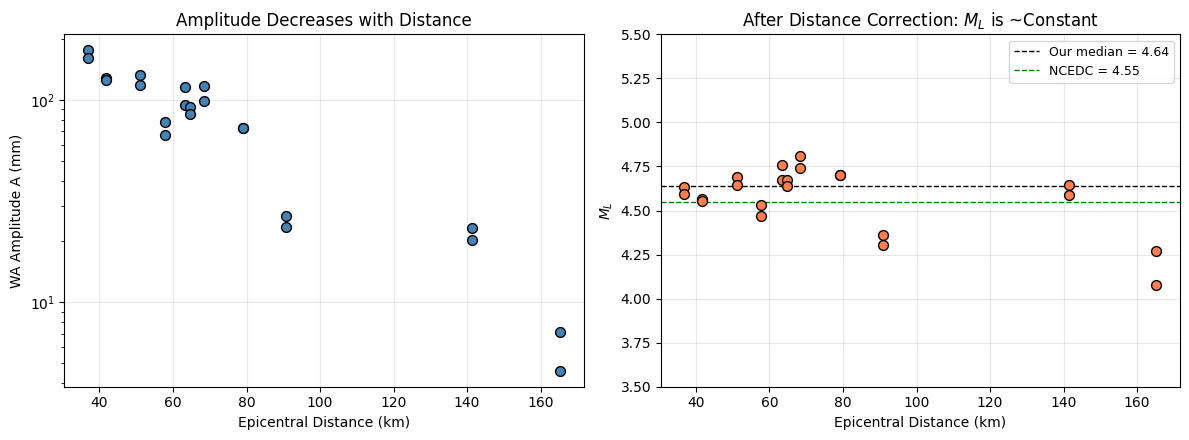

Left: Amplitude drops by ~100x from 40 km to 160 km
Right: The distance correction removes this trend → ML is ~constant


In [11]:
# Left: raw amplitude vs distance. Right: after distance correction → ML
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

dists = [r["dist_km"] for r in ml_results]
amps = [r["amp_mm"] for r in ml_results]
mls = [r["ml"] for r in ml_results]

ax1.scatter(dists, amps, c="steelblue", edgecolors="k", s=50, zorder=3)
ax1.set_xlabel("Epicentral Distance (km)")
ax1.set_ylabel("WA Amplitude A (mm)")
ax1.set_title("Amplitude Decreases with Distance")
ax1.set_yscale("log")
ax1.grid(alpha=0.3)

ax2.scatter(dists, mls, c="coral", edgecolors="k", s=50, zorder=3)
ax2.axhline(np.median(ml_all), color="k", ls="--", lw=1,
            label=f"Our median = {np.median(ml_all):.2f}")
ax2.axhline(4.55, color="green", ls="--", lw=1, label="NCEDC = 4.55")
ax2.set_xlabel("Epicentral Distance (km)")
ax2.set_ylabel("$M_L$")
ax2.set_title("After Distance Correction: $M_L$ is ~Constant")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(3.5, 5.5)

plt.tight_layout()
plt.show()

print("Left: Amplitude drops by ~100x from 40 km to 160 km")
print("Right: The distance correction removes this trend → ML is ~constant")

---
## 7. Comparing with NCEDC

How close are our measurements to the professionals? NCEDC publishes individual station $M_L$ values — let's compare ours directly.

In [12]:
# Fetch NCEDC's official station ML values from the QuakeML catalog
from xml.etree import ElementTree as ET

quakeml_url = "https://earthquake.usgs.gov/product/phase-data/nc75240492/nc/1758546070900/quakeml.xml"
resp = requests.get(quakeml_url)
root = ET.fromstring(resp.text)
ns = {"q": "http://quakeml.org/xmlns/bed/1.2"}

# Parse station ML values for our BK stations
ncedc_ml = {}
for sm in root.findall(".//q:stationMagnitude", ns):
    mag_type = sm.find("q:type", ns)
    mag_val = sm.find("q:mag/q:value", ns)
    waveform = sm.find("q:waveformID", ns)
    if mag_type is not None and mag_val is not None and mag_type.text == "ML":
        net = waveform.get("networkCode", "")
        sta = waveform.get("stationCode", "")
        chan = waveform.get("channelCode", "")
        if net == "BK" and sta in streams:
            ncedc_ml[f"{sta}.{chan[-1]}"] = float(mag_val.text)

# Compare station by station
print(f"{'Station':<10} {'Comp':<5} {'Our ML':>7} {'NCEDC':>7} {'Diff':>7}")
print("-" * 40)
diffs = []
for r in ml_results:
    key = f"{r['station']}.{r['comp']}"
    nc = ncedc_ml.get(key)
    if nc is not None:
        diff = r["ml"] - nc
        diffs.append(diff)
        print(f"  {r['station']:<8} {r['comp']:<5} {r['ml']:>6.2f} {nc:>6.2f} {diff:>+6.2f}")
print("-" * 40)
print(f"  Mean difference: {np.mean(diffs):+.2f} ± {np.std(diffs):.2f}")
print(f"\n  Our values match NCEDC\'s to within ~0.1 magnitude units!")
print(f"  The remaining differences are due to station corrections.")

Station    Comp   Our ML   NCEDC    Diff
----------------------------------------
  LCOS     N       4.63   4.60  +0.03
  LCOS     E       4.60   4.63  -0.03
  BUCI     N       4.57   4.53  +0.04
  BUCI     E       4.56   4.55  +0.01
  JASP     N       4.69   4.59  +0.10
  JASP     E       4.64   4.62  +0.02
  MLKN     N       4.47   4.37  +0.10
  MLKN     E       4.53   4.42  +0.11
  MCCM     N       4.76   4.68  +0.08
  MCCM     E       4.67   4.54  +0.13
  TESL     N       4.67   4.63  +0.04
  TESL     E       4.64   4.63  +0.01
  FARB     N       4.81   5.01  -0.20
  FARB     E       4.74   4.85  -0.11
  MHC      N       4.70   4.63  +0.07
  MHC      E       4.70   4.67  +0.03
  MTOS     N       4.36   4.32  +0.04
  MTOS     E       4.31   4.25  +0.06
  SAO      N       4.64   4.87  -0.23
  SAO      E       4.59   4.65  -0.06
  CMB      N       4.27   4.41  -0.14
  CMB      E       4.08   4.16  -0.08
----------------------------------------
  Mean difference: +0.00 ± 0.10

  Our va

---
## 8. Why Do Different Magnitude Types Disagree?

The NC network reported three magnitudes for this earthquake:

| Type | Value | What it measures |
|------|-------|-----------------|
| $M_w$ = 4.29 | Seismic moment — total energy release (low-frequency waveform modeling) |
| $M_L$ = 4.55 | Peak WA amplitude — ground shaking at ~1 Hz |
| $M_d$ = 4.63 | Coda duration — how long scattered waves persist |

Each magnitude samples a **different part of the source spectrum**:

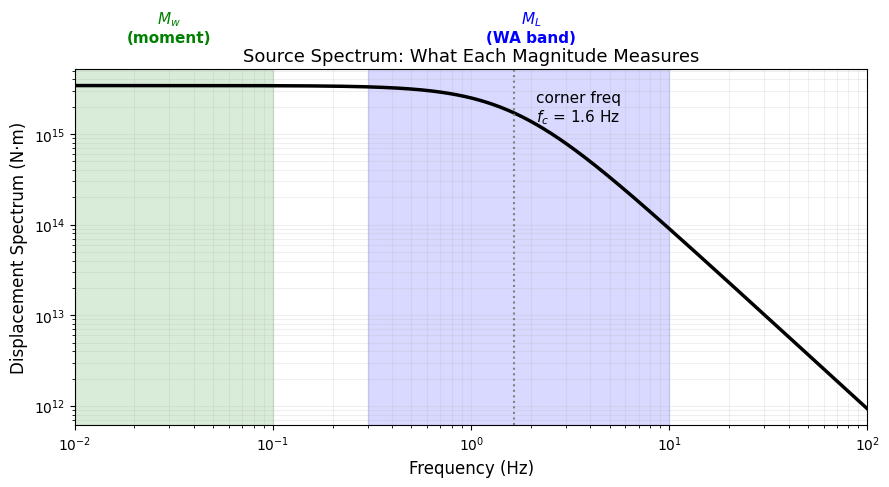

Corner frequency: fc = 1.6 Hz
Mw measures the flat part (f < fc) → total moment release
ML measures around 1 Hz → for this M4.3, fc ≈ 1.6 Hz is near the WA band


In [13]:
# Theoretical source spectrum for this earthquake (Brune 1970 model)
M0 = 10**(1.5 * 4.29 + 9.1)     # seismic moment from Mw (Kanamori formula)
stress_drop = 3e6                 # 3 MPa (typical)
beta = 3500                       # S-wave velocity (m/s)
r_source = (7 * M0 / (16 * stress_drop))**(1/3)  # source radius
fc = 2.34 * beta / (2 * np.pi * r_source)         # corner frequency

# Brune spectrum: flat below fc, falls as f^{-2} above fc
f = np.logspace(-2, 2, 1000)
spectrum = M0 / (1 + (f / fc)**2)

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(f, spectrum, "k", lw=2.5, label="Brune source spectrum")
ax.axvline(fc, color="gray", ls=":", lw=1.5)
ax.text(fc * 1.3, M0 * 0.4, f"corner freq\n$f_c$ = {fc:.1f} Hz", fontsize=11)

ax.axvspan(0.01, 0.1, alpha=0.15, color="green")
ax.text(0.03, M0 * 3, "$M_w$\n(moment)", fontsize=11, color="green",
        fontweight="bold", ha="center")

ax.axvspan(0.3, 10, alpha=0.15, color="blue")
ax.text(2, M0 * 3, "$M_L$\n(WA band)", fontsize=11, color="blue",
        fontweight="bold", ha="center")

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Displacement Spectrum (N·m)", fontsize=12)
ax.set_title("Source Spectrum: What Each Magnitude Measures", fontsize=13)
ax.set_xlim(0.01, 100)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Corner frequency: fc = {fc:.1f} Hz")
print(f"Mw measures the flat part (f < fc) → total moment release")
print(f"ML measures around 1 Hz → for this M4.3, fc ≈ {fc:.1f} Hz is near the WA band")

---
## 9. Why Do Different Agencies Disagree?

Four agencies reported this earthquake with different locations, depths, and magnitudes. Let's see their locations on a map.

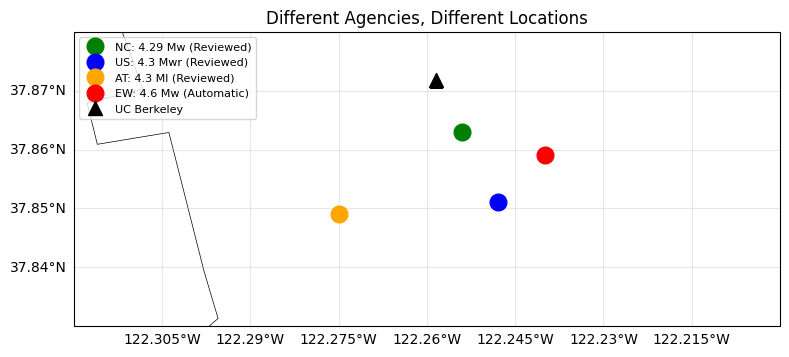

Locations differ by up to ~2 km due to different station networks,
velocity models, and quality control (automatic vs reviewed).


In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Four agencies reported different locations for this earthquake
agencies = {
    "NC": {"lat": 37.863, "lon": -122.254, "mag": 4.29, "type": "Mw",  "status": "Reviewed"},
    "US": {"lat": 37.851, "lon": -122.248, "mag": 4.3,  "type": "Mwr", "status": "Reviewed"},
    "AT": {"lat": 37.849, "lon": -122.275, "mag": 4.3,  "type": "Ml",  "status": "Reviewed"},
    "EW": {"lat": 37.859, "lon": -122.240, "mag": 4.6,  "type": "Mw",  "status": "Automatic"},
}

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-122.32, -122.20, 37.83, 37.88], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

colors = {"NC": "green", "US": "blue", "AT": "orange", "EW": "red"}
for name, info in agencies.items():
    ax.plot(info["lon"], info["lat"], "o", color=colors[name], markersize=12,
            transform=ccrs.PlateCarree(), zorder=5,
            label=f"{name}: {info['mag']} {info['type']} ({info['status']})")

ax.plot(-122.2585, 37.8719, "k^", markersize=10, transform=ccrs.PlateCarree(),
        zorder=5, label="UC Berkeley")

ax.legend(fontsize=8, loc="upper left")
ax.set_title("Different Agencies, Different Locations")
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False
plt.tight_layout()
plt.show()

print("Locations differ by up to ~2 km due to different station networks,")
print("velocity models, and quality control (automatic vs reviewed).")

---
## 10. Intensity vs Magnitude

**Magnitude** is a property of the **source** — one number per earthquake.

**Intensity** is a property of the **shaking at a location** — it varies everywhere, depending on distance, local geology, and building type.

The USGS [Did You Feel It?](https://earthquake.usgs.gov/data/dyfi/) (DYFI) system collects felt reports from the public. Let's map them.

In [15]:
# Fetch "Did You Feel It?" (DYFI) reports from the USGS
detail_url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/detail/nc75240492.geojson"
detail = requests.get(detail_url).json()

dyfi_products = detail["properties"]["products"].get("dyfi", [])
dyfi_url = None
if dyfi_products:
    contents = dyfi_products[0].get("contents", {})
    if "dyfi_zip.geojson" in contents:
        dyfi_url = contents["dyfi_zip.geojson"]["url"]

# Each report has a location, intensity (MMI scale), and number of responses
lats, lons, intensities, nresps = [], [], [], []
if dyfi_url:
    dyfi_data = requests.get(dyfi_url).json()
    for feature in dyfi_data["features"]:
        geom = feature["geometry"]
        props = feature["properties"]
        if geom["type"] == "Point":
            lons.append(geom["coordinates"][0])
            lats.append(geom["coordinates"][1])
            intensities.append(props.get("cdi", 0))
            nresps.append(props.get("nresp", 0))

lats = np.array(lats)
lons = np.array(lons)
intensities = np.array(intensities)
nresps = np.array(nresps)
print(f"Fetched {len(lats)} DYFI reports ({nresps.sum():.0f} individual responses)")

Fetched 286 DYFI reports (6030 individual responses)


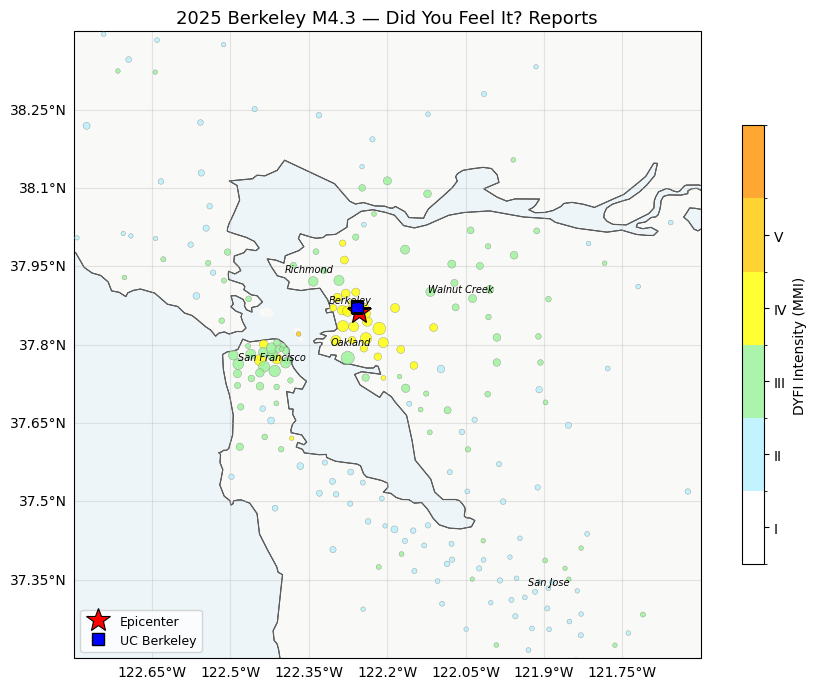

In [16]:
# Intensity map — color = MMI intensity, dot size = number of responses
from matplotlib.colors import BoundaryNorm

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-122.8, -121.6, 37.2, 38.4], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
ax.add_feature(cfeature.LAND, facecolor="#f5f5f0", alpha=0.5)
ax.add_feature(cfeature.OCEAN, facecolor="#d4e6f1", alpha=0.4)

if len(lats) > 0:
    mmi_bounds = [1, 2, 3, 4, 5, 6]
    mmi_colors = ["#ffffff", "#b4f0ff", "#96f296", "#ffff00", "#ffc800", "#ff9100"]
    cmap = plt.cm.colors.ListedColormap(mmi_colors)
    norm = BoundaryNorm(mmi_bounds + [7], cmap.N)

    sizes = np.clip(nresps, 1, 200)
    sizes = 10 + 80 * (sizes / sizes.max())

    sc = ax.scatter(lons, lats, c=intensities, cmap=cmap, norm=norm,
                    s=sizes, alpha=0.8, edgecolors="gray", linewidths=0.3,
                    transform=ccrs.PlateCarree(), zorder=3)
    cbar = plt.colorbar(sc, ax=ax, label="DYFI Intensity (MMI)", shrink=0.7,
                        ticks=[1.5, 2.5, 3.5, 4.5, 5.5])
    cbar.ax.set_yticklabels(["I", "II", "III", "IV", "V"])

ax.plot(eq_lon, eq_lat, "r*", markersize=18, markeredgecolor="k", markeredgewidth=0.8,
        transform=ccrs.PlateCarree(), label="Epicenter", zorder=6)
ax.plot(-122.2585, 37.8719, "bs", markersize=9, markeredgecolor="k",
        transform=ccrs.PlateCarree(), label="UC Berkeley", zorder=6)

cities = {"San Francisco": (-122.42, 37.77), "Oakland": (-122.27, 37.80),
          "San Jose": (-121.89, 37.34), "Berkeley": (-122.27, 37.88),
          "Richmond": (-122.35, 37.94), "Walnut Creek": (-122.06, 37.90)}
for city, (clon, clat) in cities.items():
    ax.text(clon, clat, city, fontsize=7, ha="center", transform=ccrs.PlateCarree(),
            fontstyle="italic", zorder=7)

ax.legend(loc="lower left", fontsize=9)
ax.set_title("2025 Berkeley M4.3 — Did You Feel It? Reports", fontsize=13)
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False
plt.tight_layout()
plt.show()

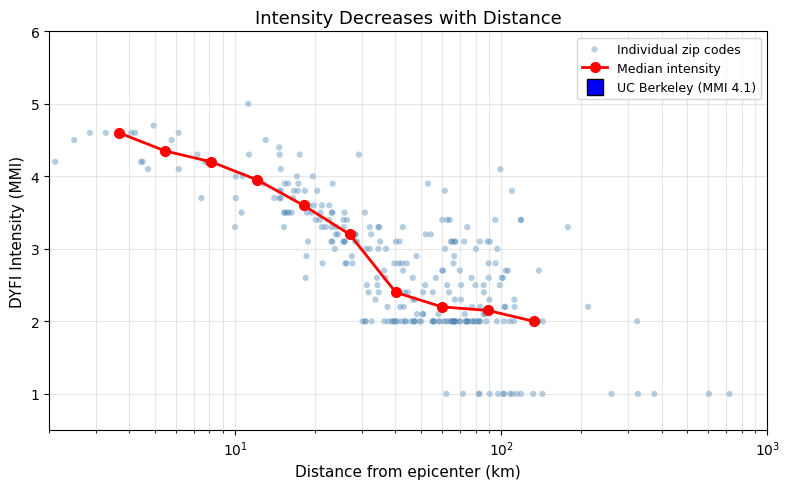

Maximum intensity (near epicenter): MMI 5.0

One earthquake, one magnitude — but intensity varies with location!


In [17]:
# Intensity vs distance from the epicenter
if len(lats) > 0:
    distances_km = np.array([gps2dist_azimuth(eq_lat, eq_lon, la, lo)[0] / 1000
                             for la, lo in zip(lats, lons)])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(distances_km, intensities,
               alpha=0.4, s=20, c="steelblue", edgecolors="none", label="Individual zip codes")

    # Median intensity in log-spaced distance bins
    dist_bins = np.logspace(np.log10(3), np.log10(800), 15)
    medians, centers = [], []
    for i in range(len(dist_bins) - 1):
        bin_mask = (distances_km >= dist_bins[i]) & (distances_km < dist_bins[i+1])
        if bin_mask.sum() > 3:
            medians.append(np.median(intensities[bin_mask]))
            centers.append(np.sqrt(dist_bins[i] * dist_bins[i+1]))
    ax.plot(centers, medians, "r-o", lw=2, markersize=7, zorder=4, label="Median intensity")

    # Mark UC Berkeley
    berk_dist = gps2dist_azimuth(eq_lat, eq_lon, 37.8719, -122.2585)[0] / 1000
    berk_mask = np.sqrt((lats - 37.8719)**2 + (lons + 122.2585)**2) < 0.02
    if berk_mask.sum() > 0:
        berk_int = np.mean(intensities[berk_mask])
        ax.plot(berk_dist, berk_int, "bs", markersize=12, zorder=5,
                markeredgecolor="k", label=f"UC Berkeley (MMI {berk_int:.1f})")

    ax.set_xscale("log")
    ax.set_xlabel("Distance from epicenter (km)", fontsize=11)
    ax.set_ylabel("DYFI Intensity (MMI)", fontsize=11)
    ax.set_title("Intensity Decreases with Distance", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which="both")
    ax.set_ylim(0.5, 6)
    ax.set_xlim(2, 1000)
    plt.tight_layout()
    plt.show()

    print(f"Maximum intensity (near epicenter): MMI {intensities.max():.1f}")
    print(f"\nOne earthquake, one magnitude — but intensity varies with location!")

---
## Summary

**Computing $M_L$ from scratch:**

$$\text{Raw counts} \xrightarrow{\text{remove response}} \text{Displacement (m)} \xrightarrow{\text{simulate WA}} \text{WA trace (mm)} \xrightarrow{A = \text{half p2p}} M_L = \log_{10} A + \log_{10} R + 0.00301R + 0.70$$

**Key takeaways:**

| | |
|---|---|
| **We reproduced the catalog** | Our $M_L$ ≈ 4.55, matching NCEDC's value |
| **$M_w \neq M_L \neq M_d$** | They measure different physical properties of the source |
| **Agencies disagree** | Different networks, models, formulas, and quality control |
| **Magnitude ≠ Intensity** | Magnitude = source property (one number). Intensity = local shaking (varies everywhere) |